In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("data/weather.csv")
print(df)

            date  precipitation  temp_max  temp_min  wind  weather
0     2012-01-01            0.0      12.8       5.0   4.7  drizzle
1     2012-01-02           10.9      10.6       2.8   4.5     rain
2     2012-01-03            0.8      11.7       7.2   2.3     rain
3     2012-01-04           20.3      12.2       5.6   4.7     rain
4     2012-01-05            1.3       8.9       2.8   6.1     rain
...          ...            ...       ...       ...   ...      ...
1456  2015-12-27            8.6       4.4       1.7   2.9     rain
1457  2015-12-28            1.5       5.0       1.7   1.3     rain
1458  2015-12-29            0.0       7.2       0.6   2.6      fog
1459  2015-12-30            0.0       5.6      -1.0   3.4      sun
1460  2015-12-31            0.0       5.6      -2.1   3.5      sun

[1461 rows x 6 columns]


In [4]:
print(df.dtypes)

date                 str
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
weather              str
dtype: object


In [8]:
print(type(df))
df.info()

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   str    
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   str    
dtypes: float64(4), str(2)
memory usage: 88.0 KB


In [9]:
print(df.date)

0       2012-01-01
1       2012-01-02
2       2012-01-03
3       2012-01-04
4       2012-01-05
           ...    
1456    2015-12-27
1457    2015-12-28
1458    2015-12-29
1459    2015-12-30
1460    2015-12-31
Name: date, Length: 1461, dtype: str


In [11]:
print(df['date'])

0       2012-01-01
1       2012-01-02
2       2012-01-03
3       2012-01-04
4       2012-01-05
           ...    
1456    2015-12-27
1457    2015-12-28
1458    2015-12-29
1459    2015-12-30
1460    2015-12-31
Name: date, Length: 1461, dtype: str


In [14]:
df[['date','temp_max']]

,date,temp_max
0,2012-01-01,12.8
1,2012-01-02,10.6
2,2012-01-03,11.7
3,2012-01-04,12.2
4,2012-01-05,8.9
...,...,...
1456,2015-12-27,4.4
1457,2015-12-28,5.0
1458,2015-12-29,7.2
1459,2015-12-30,5.6


In [17]:
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [28]:
df['month']=pd.to_datetime(df['date']).dt.to_period('M').astype(str)

In [29]:
df_groupby_date=df.groupby('month')

In [30]:
month_temp=df_groupby_date[["temp_max",'temp_min']]

In [31]:
month_temp_mean=month_temp.mean()

In [ ]:
%%sql


In [33]:
month_temp_mean = df.groupby('month')[["temp_max", "temp_min"]].mean()
month_temp_mean

,temp_max,temp_min
month,,
2012-01,7.054839,1.541935
2012-02,9.275862,3.203448
2012-03,9.554839,2.838710
2012-04,14.873333,5.993333
2012-05,17.661290,8.190323
2012-06,18.693333,10.480000
2012-07,22.906452,12.932258
2012-08,25.858065,14.009677
2012-09,22.880000,11.243333


In [35]:
df.groupby('month')['weather'].nunique()

month
2012-01    4
2012-02    4
2012-03    4
2012-04    4
2012-05    3
2012-06    3
2012-07    4
2012-08    3
2012-09    4
2012-10    3
2012-11    4
2012-12    4
2013-01    4
2013-02    3
2013-03    5
2013-04    4
2013-05    3
2013-06    2
2013-07    2
2013-08    3
2013-09    3
2013-10    3
2013-11    4
2013-12    3
2014-01    3
2014-02    3
2014-03    3
2014-04    2
2014-05    2
2014-06    2
2014-07    3
2014-08    3
2014-09    3
2014-10    3
2014-11    4
2014-12    3
2015-01    3
2015-02    3
2015-03    3
2015-04    3
2015-05    3
2015-06    4
2015-07    4
2015-08    4
2015-09    3
2015-10    4
2015-11    3
2015-12    3
Name: weather, dtype: int64

<Axes: xlabel='month'>

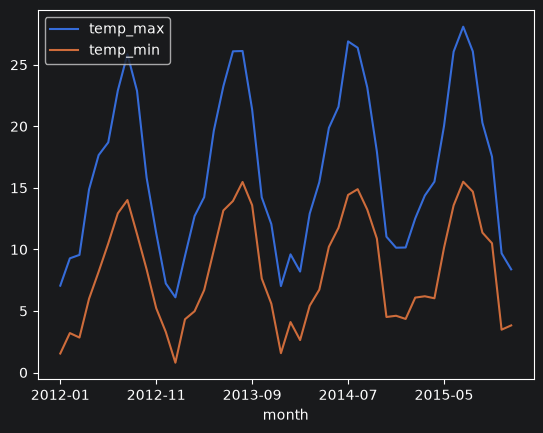

In [39]:
df.groupby('month')[['temp_max','temp_min']].mean().plot()

In [40]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [41]:
df.describe(include='all')

,date,precipitation,temp_max,temp_min,wind,weather,month
count,1461,1461.000000,1461.000000,1461.000000,1461.000000,1461,1461
unique,1461,NaN,NaN,NaN,NaN,5,48
top,2012-01-01,NaN,NaN,NaN,NaN,rain,2012-01
freq,1,NaN,NaN,NaN,NaN,641,31
mean,NaN,3.029432,16.439083,8.234771,3.241136,NaN,NaN
std,NaN,6.680194,7.349758,5.023004,1.437825,NaN,NaN
min,NaN,0.000000,-1.600000,-7.100000,0.400000,NaN,NaN
25%,NaN,0.000000,10.600000,4.400000,2.200000,NaN,NaN
50%,NaN,0.000000,15.600000,8.300000,3.000000,NaN,NaN
75%,NaN,2.800000,22.200000,12.200000,4.000000,NaN,NaN


In [42]:
df.describe(include=['float64'])

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [43]:
df.nlargest(30,'temp_max')

,date,precipitation,temp_max,temp_min,wind,weather,month
953,2014-08-11,0.5,35.6,17.8,2.6,rain,2014-08
1295,2015-07-19,0.0,35.0,17.2,3.3,sun,2015-07
228,2012-08-16,0.0,34.4,18.3,2.8,sun,2012-08
912,2014-07-01,0.0,34.4,15.6,3.5,sun,2014-07
1306,2015-07-30,0.0,34.4,17.2,3.5,sun,2015-07
1307,2015-07-31,0.0,34.4,17.8,2.6,sun,2015-07
216,2012-08-04,0.0,33.9,16.7,3.7,sun,2012-08
217,2012-08-05,0.0,33.9,17.8,1.9,sun,2012-08
546,2013-06-30,0.0,33.9,17.2,2.5,sun,2013-06
619,2013-09-11,0.0,33.9,16.1,2.4,sun,2013-09


In [45]:
df.nlargest(30,'temp_max').nsmallest(5,'temp_min')

,date,precipitation,temp_max,temp_min,wind,weather,month
250,2012-09-07,0.0,32.2,13.3,3.1,sun,2012-09
1305,2015-07-29,0.0,32.2,14.4,3.8,sun,2015-07
945,2014-08-03,0.0,31.7,14.4,2.6,sun,2014-08
1280,2015-07-04,0.0,33.3,15.0,2.9,sun,2015-07
979,2014-09-06,0.0,32.2,15.0,2.9,sun,2014-09


In [46]:
df['year']=pd.to_datetime(df['date']).dt.to_period('Y').astype(str)

In [47]:
print(df)

            date  precipitation  temp_max  temp_min  wind  weather    month  \
0     2012-01-01            0.0      12.8       5.0   4.7  drizzle  2012-01   
1     2012-01-02           10.9      10.6       2.8   4.5     rain  2012-01   
2     2012-01-03            0.8      11.7       7.2   2.3     rain  2012-01   
3     2012-01-04           20.3      12.2       5.6   4.7     rain  2012-01   
4     2012-01-05            1.3       8.9       2.8   6.1     rain  2012-01   
...          ...            ...       ...       ...   ...      ...      ...   
1456  2015-12-27            8.6       4.4       1.7   2.9     rain  2015-12   
1457  2015-12-28            1.5       5.0       1.7   1.3     rain  2015-12   
1458  2015-12-29            0.0       7.2       0.6   2.6      fog  2015-12   
1459  2015-12-30            0.0       5.6      -1.0   3.4      sun  2015-12   
1460  2015-12-31            0.0       5.6      -2.1   3.5      sun  2015-12   

      year  
0     2012  
1     2012  
2     2012  

In [48]:
df

,date,precipitation,temp_max,temp_min,wind,weather,month,year
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle,2012-01,2012
1,2012-01-02,10.9,10.6,2.8,4.5,rain,2012-01,2012
2,2012-01-03,0.8,11.7,7.2,2.3,rain,2012-01,2012
3,2012-01-04,20.3,12.2,5.6,4.7,rain,2012-01,2012
4,2012-01-05,1.3,8.9,2.8,6.1,rain,2012-01,2012
...,...,...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain,2015-12,2015
1457,2015-12-28,1.5,5.0,1.7,1.3,rain,2015-12,2015
1458,2015-12-29,0.0,7.2,0.6,2.6,fog,2015-12,2015
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun,2015-12,2015


In [49]:
df_sort=df.sort_values(['year','temp_max'],ascending=[True,False])

,date,precipitation,temp_max,temp_min,wind,weather,month,year
228,2012-08-16,0.0,34.4,18.3,2.8,sun,2012-08,2012
216,2012-08-04,0.0,33.9,16.7,3.7,sun,2012-08,2012
217,2012-08-05,0.0,33.9,17.8,1.9,sun,2012-08,2012
229,2012-08-17,0.0,32.8,16.1,1.8,sun,2012-08,2012
250,2012-09-07,0.0,32.2,13.3,3.1,sun,2012-09,2012
...,...,...,...,...,...,...,...,...
1454,2015-12-25,5.8,5.0,2.2,1.5,rain,2015-12,2015
1457,2015-12-28,1.5,5.0,1.7,1.3,rain,2015-12,2015
1455,2015-12-26,0.0,4.4,0.0,2.5,sun,2015-12,2015
1456,2015-12-27,8.6,4.4,1.7,2.9,rain,2015-12,2015


In [53]:
df_sort.drop_duplicates(subset='year')

,date,precipitation,temp_max,temp_min,wind,weather,month,year
228,2012-08-16,0.0,34.4,18.3,2.8,sun,2012-08,2012
546,2013-06-30,0.0,33.9,17.2,2.5,sun,2013-06,2013
953,2014-08-11,0.5,35.6,17.8,2.6,rain,2014-08,2014
1295,2015-07-19,0.0,35.0,17.2,3.3,sun,2015-07,2015
